# 모델의 성능 향상시키기

1. 데이터의 확인과 검증셋

In [ ]:
# ===============================
# 1. 필요한 라이브러리 불러오기
# ===============================

# Sequential : 신경망의 층을 위에서 아래로
#              순서대로 쌓는 모델
# Dense      : 모든 노드가 서로 연결된 기본 레이어
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# train_test_split : 데이터를
# 학습용 / 테스트용으로 나누는 함수
from sklearn.model_selection import train_test_split

# pandas : CSV 파일을 표 형태(DataFrame)로 다루기 위한 라이브러리
import pandas as pd


# ===============================
# 2. 데이터 불러오기
# ===============================

# wine.csv 파일을 읽어서 df에 저장
# header=None :
#  - 컬럼 이름이 없는 데이터
#  - 0, 1, 2, ... 자동 번호 부여
df=pd.read_csv('./wine.csv',header=None)

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
df

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,0
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,0
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,0
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,0


In [ ]:
# ===============================
# 3. 입력 데이터(X)와 정답(y) 분리
# ===============================

# X : 입력 데이터 (특징, 문제지)
# 모든 행(:)에서
# 0번 ~ 11번 열까지 선택 → 총 12개의 입력값
X=df.iloc[:,0:12]

# y : 정답 데이터 (라벨, 답지)
# 모든 행(:)에서
# 12번째 열 하나만 선택
# → 결과값 (0 또는 1)
y=df.iloc[:,12]

In [ ]:
# ===============================
# 4. 학습용 / 테스트용 데이터 분리
# ===============================

# 전체 데이터를 섞은 뒤(shuffle=True)
# 80%는 학습용
# 20%는 테스트용으로 분리
X_train,X_test,y_train,y_test=train_test_split(X, # 입력 데이터
                                               y, # 정답 데이터
                                               test_size=0.2, # 테스트 데이터 비율 (20%)
                                               shuffle=True) # 데이터 섞기


# ===============================
# 5. 신경망 모델 생성
# ===============================

# 순차적으로 층을 쌓는 신경망 생성
model=Sequential()


# ===============================
# 6. 첫 번째 은닉층
# ===============================

# Dense(30, input_dim=12, activation='relu')
#
# - input_dim=12 :
#   입력 데이터의 특징 개수 (X의 열 개수)
#
# - 30 :
#   이 층의 뉴런 개수
#   → 12개의 정보를 30개의 관점으로 해석
#
# - activation='relu' :
#   ReLU 활성화 함수
#   → 음수는 0, 양수는 그대로 전달
#   → 딥러닝에서 가장 많이 쓰임
model.add(Dense(30,input_dim=12,activation='relu'))

# ===============================
# 7. 두 번째 은닉층
# ===============================

# 첫 번째 층에서 나온 30개의 정보를
# 12개의 더 중요한 특징으로 압축
model.add(Dense(12,activation='relu'))

# ===============================
# 8. 세 번째 은닉층
# ===============================

# 다시 한 번 중요한 정보만 남기기 위해
# 12개 → 8개로 축소
model.add(Dense(8,activation='relu'))


# ===============================
# 9. 출력층 (가장 중요)
# ===============================

# Dense(1, activation='sigmoid')
#
# - 뉴런 1개 :
#   최종 결과를 하나의 숫자로 출력
#
# - sigmoid :
#   출력값을 0~1 사이 확률로 변환
#   → 0에 가까우면 클래스 0
#   → 1에 가까우면 클래스 1
#
# 이진 분류 문제의 정석적인 출력층
model.add(Dense(1,activation='sigmoid'))


# ===============================
# 10. 모델 구조 확인
# ===============================

# 지금까지 쌓은 신경망 구조를
# 한눈에 확인하기 위한 출력
model.summary()

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           372 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 875 (3.42 KB)

 Trainable params: 875 (3.42 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ===============================
# 1. 모델 컴파일 (공부 규칙 정하기)
# ===============================

model.compile(
    # loss (손실 함수)
    # → 모델이 "얼마나 틀렸는지" 계산하는 기준
    # binary_crossentropy :
    #  - 정답이 0 또는 1인 문제(이진 분류)에 사용
    #  - 예측이 틀릴수록 큰 벌점을 줌
    #  - 출력층이 sigmoid일 때 가장 잘 맞음
              loss='binary_crossentropy',
    # optimizer (최적화 알고리즘)
    # → 틀린 만큼 가중치를 어떻게 고칠지 결정
    # adam :
    #  - 학습 속도를 자동으로 조절
    #  - 방향도 자동으로 잘 잡아줌
    #  - 초보자부터 실무까지 가장 많이 쓰임
              optimizer='adam',
    # metrics (학습 중 같이 볼 지표)
    # accuracy :
    #  - 전체 예측 중 맞춘 비율
    #  - 사람이 이해하기 쉬운 성능 지표
              metrics=['accuracy'])


# ===============================
# 2. 모델 학습 시작
# ===============================
history=model.fit( # X_train :
                   #  - 학습에 사용할 입력 데이터 (문제)
                  X_train,

                   # y_train :
                   #  - 학습에 사용할 정답 데이터 (답지)
                  y_train,
                    # epochs=50 :
                    #  - 전체 학습 데이터를
                    #    처음부터 끝까지 50번 반복해서 학습
                    #  - 너무 작으면 덜 배움
                    #  - 너무 크면 외워버릴 수 있음(과적합)
                  epochs=50,

                     # batch_size=500 :
                    #  - 데이터를 500개씩 묶어서 학습
                    #  - 값이 크면 학습은 빠르지만 세밀함은 줄어듦
                    #  - 값이 작으면 느리지만 더 정교하게 학습
                  batch_size=500,

                    # validation_split=0.25 :
                    #  - X_train, y_train 중
                    #    25%는 학습에 쓰지 않고 "검증용"으로 따로 떼어둠
                    #  - 매 epoch마다:
                    #      1) 학습 데이터로 공부
                    #      2) 검증 데이터로 시험
                    #  - 과적합 여부를 확인하기 위해 필수
                  validation_split=0.25)



# history 변수에는
# 매 epoch마다의 결과가 저장됨
# 예:
#  - history.history['loss']          → 학습 손실
#  - history.history['accuracy']      → 학습 정확도
#  - history.history['val_loss']      → 검증 손실
#  - history.history['val_accuracy']  → 검증 정확도

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7549 - loss: 1.7877 - val_accuracy: 0.7631 - val_loss: 0.6270
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7688 - loss: 0.4676 - val_accuracy: 0.8369 - val_loss: 0.3853
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8625 - loss: 0.3638 - val_accuracy: 0.8800 - val_loss: 0.3121
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8653 - loss: 0.3293 - val_accuracy: 0.8792 - val_loss: 0.3120
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8902 - loss: 0.3164 - val_accuracy: 0.9208 - val_loss: 0.3005
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9115 - loss: 0.3084 - val_accuracy: 0.9169 - val_loss: 0.2906
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9053 - loss: 0.3004 - val_accuracy: 0.9154 - val_loss: 0.2855
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9133 - loss: 0.2942 - val_accuracy: 0.9246 - val_loss: 0.2790
Epoch 9

In [ ]:
# ===============================
# 1. 테스트 데이터로 모델 평가
# ===============================

# model.evaluate()
# → 학습이 끝난 모델에게
#   "이 시험지(X_test)를 풀어봐"라고 시키는 함수
# → X_test는 모델이 처음 보는 데이터
# → y_test는 그에 대한 정답

# evaluate의 결과는 리스트 형태로 반환됨
# [loss, accuracy]

score=model.evaluate(X_test,y_test)


# ===============================
# 2. 정확도 출력
# ===============================

# score[0] : loss (얼마나 틀렸는지)
# score[1] : accuracy (얼마나 맞았는지)

# 우리가 보고 싶은 건
# "테스트 데이터에서의 정확도"
print('Test accuracy:',score[1])

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9377 - loss: 0.2028 
Test accuracy: 0.9376922845840454


## 모델 업데이트하기

In [ ]:
# ===============================
# 1. 신경망 모델 관련 라이브러리
# ===============================

# Sequential :
# 신경망의 층(layer)을
# 위에서 아래로 순서대로 쌓는 모델
from tensorflow.keras.models import Sequential

# Dense :
# 모든 뉴런이 서로 연결된
# 가장 기본적인 신경망 층
from tensorflow.keras.layers import Dense

# ModelCheckpoint :
# 학습 중에 성능이 가장 좋았던 모델만
# 자동으로 저장해주는 기능
from tensorflow.keras.callbacks import ModelCheckpoint

# ===============================
# 2. 데이터 분리 관련 라이브러리
# ===============================

# train_test_split :
# 전체 데이터를
# 학습용(train) / 테스트용(test)으로
# 나누기 위한 함수
from sklearn.model_selection import train_test_split

# ===============================
# 3. 기본 라이브러리
# ===============================

# os :
# 파일 경로 확인, 폴더 생성 등
# 파일 관련 작업에 사용
import os
# pandas :
# CSV 파일을 표 형태(DataFrame)로 다루기 위한 라이브러리
import pandas as pd
# numpy :
# 숫자 계산, 배열 연산을 위한 라이브러리
import numpy as np

# matplotlib :
# 학습 결과(accuracy, loss)를
# 그래프로 시각화할 때 사용
import matplotlib.pyplot as plt




# ===============================
# 4. 데이터 불러오기
# ===============================

# wine.csv 파일을 읽어서 df(DataFrame)에 저장
# header=None :
# 컬럼 이름이 없는 데이터이기 때문에
# 0, 1, 2, ... 숫자로 컬럼 번호를 자동 지정
df=pd.read_csv("./wine.csv",header=None)


# ===============================
# 5. 입력 데이터(X)와 정답(y) 분리
# ===============================

# X : 입력 데이터 (문제지)
# 모든 행(:)에서
# 0번 ~ 11번 열까지 선택 → 총 12개의 특징
X=df.iloc[:,0:12]

# y : 정답 데이터 (답지)
# 모든 행(:)에서
# 12번째 열 하나만 선택
# 값은 0 또는 1 → 이진 분류
y=df.iloc[:,12]


# ===============================
# 6. 학습용 / 테스트용 데이터 분리
# ===============================

# 전체 데이터를 섞은 후(shuffle=True)
# 80%는 학습용
# 20%는 테스트용으로 나눔
X_train,X_test,y_train,y_test=train_test_split(X,# 입력 데이터
                                               y,# 정답 데이터
                                               test_size=0.2,# 테스트 데이터 비율 (20%)
                                               shuffle=True)  # 데이터 섞기 (편향 방지)


# ===============================
# 7. 신경망 모델 생성
# ===============================

# Sequential 모델 생성
# (아직 아무 층도 없는 빈 신경망)
model=Sequential()

# ===============================
# 8. 첫 번째 은닉층
# ===============================

# Dense(30, input_dim=12, activation='relu')
#
# input_dim=12 :
# 입력 데이터의 특징 개수
# (와인 성분 12개)
#
# 30 :
# 이 층의 뉴런 개수
# → 12개의 정보를 30개의 관점으로 분석
#
# relu :
# 음수는 0으로 만들고
# 중요한 정보만 통과시키는 활성화 함수
model.add(Dense(30,input_dim=12,activation='relu'))

# ===============================
# 9. 두 번째 은닉층
# ===============================

# 첫 번째 층에서 나온 30개의 정보를
# 12개의 더 중요한 특징으로 압축
model.add(Dense(12,activation='relu'))

# ===============================
# 10. 세 번째 은닉층
# ===============================

# 다시 한 번 압축
# → 정답에 더 가까운 핵심 정보만 남김
model.add(Dense(8,activation='relu'))



# ===============================
# 11. 출력층 (가장 중요)
# ===============================

# Dense(1, activation='sigmoid')
#
# 뉴런 1개 :
# 최종 결과를 하나의 값으로 출력
#
# sigmoid :
# 출력값을 0 ~ 1 사이 확률로 변환
# → 0에 가까우면 클래스 0
# → 1에 가까우면 클래스 1
#
# 이진 분류 문제의 표준 출력층
model.add(Dense(1,activation='sigmoid'))
model.summary()


model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 30)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 12)             │           372 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 875 (3.42 KB)

 Trainable params: 875 (3.42 KB)

 Non-trainable params: 0 (0.00 B)

#### 검증데이터가 왜 필요한지


아주 좋은 질문이야 👍
여기서 말한 **“훈련을 조절한다”**는 말이 추상적으로 느껴지는 게 당연해.
그래서 **결론 → 구체적인 행동 → 실제 예** 순서로 설명할게.

---

## 🔴 한 문장으로 먼저 말하면

> **훈련을 조절한다는 건
> “모델이 어떻게, 얼마나, 언제까지 공부할지”를
> 검증 데이터 결과를 보고 결정한다는 뜻이야.**

---

## 1️⃣ 딥러닝 훈련에서 “조절”이 필요한 이유

모델은 **가만두면 무조건 더 공부하려고만 해**.

```text
epoch 1  → 조금 배움
epoch 20 → 잘 배움
epoch 50 → 외우기 시작
epoch 100 → 완전히 외움 (과적합)
```

❗ 모델은 **스스로 멈출 줄 모름**
👉 그래서 **사람 대신 판단해주는 기준**이 필요
👉 그 기준이 **검증(validation) 결과**

---

## 2️⃣ “훈련을 조절한다” = 실제로 뭘 조절하냐?

### 🔹 조절하는 것 ① 언제 멈출지

#### 👉 EarlyStopping

```python
EarlyStopping(monitor='val_loss', patience=5)
```

의미:

* 검증 성능이 좋아지지 않으면
* **“이제 그만 공부해”** 하고 멈춤

📌 검증 데이터 없으면?

* 멈출 기준이 없음 ❌

---

### 🔹 조절하는 것 ② 어떤 모델을 쓸지

#### 👉 ModelCheckpoint

```python
ModelCheckpoint(
    monitor='val_accuracy',
    save_best_only=True
)
```

의미:

* 여러 epoch 중에서
* **검증 성능이 제일 좋았던 모델만 선택**

📌 마지막 모델 ❌
📌 **검증 기준 최고 모델 ⭕**

---

### 🔹 조절하는 것 ③ 하이퍼파라미터 선택

예를 들어:

```text
모델 A → val_accuracy 0.91
모델 B → val_accuracy 0.88
```

👉 **A를 선택**

이건 이미:

* 은닉층 개수
* 뉴런 수
* batch_size
* learning rate

같은 **훈련 설정을 조절한 결과**

---

## 3️⃣ 중요한 포인트 ⭐⭐⭐

### “검증 데이터는 학습에 쓰이지 않지만, 학습에 영향을 준다”

이 말이 헷갈리는데, 이렇게 이해하면 돼 👇

| 구분             | 가중치 업데이트   |
| -------------- | ---------- |
| train 데이터      | ⭕ 직접 업데이트  |
| validation 데이터 | ❌ 업데이트 안 함 |

❗ 하지만 validation은

* 언제 멈출지
* 어떤 모델을 고를지
* 어떤 설정이 좋은지

👉 **의사결정에 사용됨**

그래서 **간접적으로 훈련을 조절**

---

## 4️⃣ 비유로 다시 설명 (이게 제일 직관적)

### 📘 공부 비유

* **Train** → 문제집 풀기 (실제 공부)
* **Validation** → 모의고사
* **Test** → 수능

모의고사 점수로 뭘 하냐면 👇

* “이제 더 공부 안 해도 되겠다” → ❌ 멈춤
* “이 공부법이 낫네” → ❌ 방법 변경
* “이 시점 성적이 제일 좋네” → ❌ 그 상태 저장

👉 이게 바로 **훈련 조절**

---

## 5️⃣ 그래서 validation만으로 끝내면 안 되는 이유

> ❌ validation은 이미
> “훈련 과정에 활용된 데이터”

그래서 마지막에 반드시:

```python
model.evaluate(X_test, y_test)
```

👉 **완전히 독립된 최종 시험**이 필요

---

## 🔥 핵심 요약 (이 문장만 기억해도 됨)

> **훈련을 조절한다는 건
> 검증 성능을 보고
> 언제 멈출지, 어떤 모델을 쓸지,
> 어떤 설정이 좋은지 결정하는 것이다.**

---



In [ ]:
# ===============================
# 1. 모델 저장 파일 이름 규칙 설정
# ===============================

# modelpath :
# 모델이 저장될 때 사용할 파일 이름 형식
# 중괄호 {} 안의 값들은
# 학습 중 자동으로 실제 값으로 바뀜

modelpath="./{epoch:02d}-{val_accuracy:.4f}.keras"


# {epoch:02d} :
# - 현재 학습 반복 횟수(epoch)
# - 두 자리 숫자로 표시
#   예) 01, 02, 10
#
# {val_accuracy:.4f} :
# - 검증 정확도(validation accuracy)
# - 소수점 4자리까지 표시
#   예) 0.9123


# ===============================
# 2. ModelCheckpoint 객체 생성
# ===============================

# ModelCheckpoint :
# 학습 중 매 epoch가 끝날 때마다
# 모델을 자동으로 저장해주는 감시자
checkpointer=ModelCheckpoint(filepath=modelpath,# 위에서 정한 파일 이름 규칙 사용
                             verbose=1) # 저장될 때마다 메시지 출력


# verbose=1 이면
# 다음과 같은 메시지가 출력됨:
# "Epoch 12: saving model to ./12-0.9143.keras"


# ===============================
# 3. 모델 학습 시작 + 자동 저장
# ===============================

histroy=model.fit( # X_train :
                  # 학습에 사용할 입력 데이터 (문제)
                  X_train,
                  # y_train :
                  # 학습에 사용할 정답 데이터 (답지)
                  y_train,
                  
                # epochs=50 :
                # 전체 데이터를 처음부터 끝까지
                # 총 50번 반복해서 학습
                  epochs=50,

                # batch_size=500 :
                # 데이터를 500개씩 묶어서 학습
                # 값이 클수록 학습은 빠르지만
                # 세밀함은 다소 떨어질 수 있음
                  batch_size=500,

                # validation_split=0.25 :
                # 학습 데이터 중
                # 25%는 검증용으로 따로 떼어둠
                # → 학습에는 사용 ❌
                # → 성능 확인(시험)에만 사용 ⭕
                  validation_split=0.25,

                # verbose=0 :
                # 학습 과정 출력 안 함
                # (checkpoint 메시지만 보고 싶을 때 사용)
                  verbose=0,

                # callbacks :
                # 학습 중 함께 실행할 기능 목록
                # checkpointer :
                # 매 epoch마다 모델을 자동 저장
                  callbacks=[checkpointer])

# history 변수에는
# 매 epoch마다의
# loss, accuracy, val_loss, val_accuracy
# 값들이 저장됨


Epoch 1: saving model to ./01-0.9292.keras

Epoch 1: finished saving model to ./01-0.9292.keras

Epoch 2: saving model to ./02-0.9200.keras

Epoch 2: finished saving model to ./02-0.9200.keras

Epoch 3: saving model to ./03-0.9285.keras

Epoch 3: finished saving model to ./03-0.9285.keras

Epoch 4: saving model to ./04-0.9362.keras

Epoch 4: finished saving model to ./04-0.9362.keras

Epoch 5: saving model to ./05-0.9362.keras

Epoch 5: finished saving model to ./05-0.9362.keras

Epoch 6: saving model to ./06-0.9354.keras

Epoch 6: finished saving model to ./06-0.9354.keras

Epoch 7: saving model to ./07-0.9369.keras

Epoch 7: finished saving model to ./07-0.9369.keras

Epoch 8: saving model to ./08-0.9369.keras

Epoch 8: finished saving model to ./08-0.9369.keras

Epoch 9: saving model to ./09-0.9369.keras

Epoch 9: finished saving model to ./09-0.9369.keras

Epoch 10: saving model to ./10-0.9369.keras

Epoch 10: finished saving model to ./10-0.9369.keras

Epoch 11: saving model to .

In [ ]:
# ===============================
# 1. 테스트 데이터로 모델 최종 평가
# ===============================

# model.evaluate()
# → 학습이 전부 끝난 모델에게
#   "이 시험지(X_test)를 풀어봐"라고 시키는 함수
# → X_test는 모델이 처음 보는 데이터
# → y_test는 그에 대한 정답
#
# 반환값은 리스트 형태:
# [loss, accuracy]
score=model.evaluate(X_test,y_test)


# score[0] : loss  (얼마나 틀렸는지)
# score[1] : accuracy (얼마나 맞았는지)
print("Test accuracy:",score[1])

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9415 - loss: 0.1419
Test accuracy: 0.9415384531021118


## 그래프로 과적합확인하기

In [ ]:
# ===============================
# 2. 콜백(callback) 관련 라이브러리
# ===============================

# LambdaCallback :
# 학습 도중 특정 시점(예: epoch 끝)에
# 내가 만든 함수를 실행할 수 있게 해주는 도구

from tensorflow.keras.callbacks import LambdaCallback


# tensorflow :
# tf.print 같은 텐서플로 전용 출력 함수 사용
import tensorflow as tf

# ===============================
# 3. 학습 상태를 출력하는 사용자 정의 함수
# ===============================

# 이 함수는 "epoch 하나가 끝날 때마다" 자동 호출됨
# epoch : 현재 몇 번째 epoch인지 (0부터 시작)
# logs  : 현재 epoch의 학습 결과들이 담긴 딕셔너리
def custom_log(epoch,logs):

    # 50 epoch마다 한 번씩만 출력
    # epoch는 0부터 시작하므로 +1
    if (epoch +1) %50 ==0:
        # 한 epoch에 몇 번의 batch가 있는지 계산
        # 예: 훈련 데이터 5000개, batch_size=500
        # → 10 batch
        num_batches=len(X_train) // 500
        # 현재 epoch 진행 상황 출력
        # 예: Epoch 50/2000
        print(f"Epoch {epoch+1}/2000")
        # tf.print :
        # 텐서플로 환경에서도 안정적으로 출력되는 함수
        # logs 딕셔너리 안의 값들을 꺼내서 출력
        tf.print(f"{num_batches}/{num_batches}"
                 f"accuracy :{logs['accuracy']:.4f} - loss:{logs['loss']:.4f}"
                 f"val_accuracy:{logs['val_accuracy']:.4f}-val_loss:{logs['val_loss']:.4f}")

    # logs 안에 들어있는 값 설명:
        # logs['accuracy']      → 학습 데이터 정확도
        # logs['loss']          → 학습 데이터 손실
        # logs['val_accuracy']  → 검증 데이터 정확도
        # logs['val_loss']      → 검증 데이터 손실
        #
        # .4f :
        # 소수점 4자리까지 깔끔하게 출력


# ===============================
# 4. LambdaCallback으로 함수 연결
# ===============================

# LambdaCallback :
# "epoch이 끝날 때(on_epoch_end)"
# custom_log 함수를 실행하도록 설정

show_status=LambdaCallback(on_epoch_end=custom_log)

In [ ]:
# 모델을 학습시키고, 학습 과정을 history 변수에 저장
history=model.fit(
    X_train,
     # ▶ 입력 데이터 (문제지)
    # ▶ 모델이 보고 학습할 특징(feature)들
    # ▶ 예: 키, 몸무게 / 집 크기, 방 개수 등
    y_train,
    # ▶ 정답 데이터 (답지)
    # ▶ X_train에 대한 실제 정답 값
    # ▶ 모델이 맞춰야 할 목표 값
    epochs=2000,
     # ▶ 전체 학습 데이터를 몇 번 반복해서 학습할지
    # ▶ 1 epoch = 전체 데이터를 한 번 모두 학습
    # ▶ 2000번 반복해서 점점 오차를 줄여나감
    # ▶ 너무 적으면 덜 배움, 너무 많으면 과적합 위험
    batch_size=500,
      # ▶ 한 번에 몇 개의 데이터씩 나눠서 학습할지
    # ▶ 전체 데이터를 500개씩 잘라서 여러 번 학습
    # ▶ 메모리 사용량과 학습 속도에 영향을 줌
    validation_split=0.25,
      # ▶ 훈련 데이터 중 25%를 검증용 데이터로 사용
    # ▶ 실제 학습에는 사용하지 않고 성능 확인용
    # ▶ 과적합 여부를 확인하는 데 매우 중요
    verbose=0,
        # ▶ 학습 과정 출력 여부
    # ▶ 0: 아무것도 출력하지 않음
    # ▶ 1: 진행바와 로그 출력
    # ▶ 2: epoch 단위 로그만 출력
    callbacks=show_status
      # ▶ 학습 도중 실행되는 추가 기능(콜백)
    # ▶ 예: 중간 상태 출력, 조기 종료, 모델 저장 등
    # ▶ show_status는 사용자가 정의한 콜백일 가능성 큼
)

Epoch 50/2000
10/10accuracy :0.9774 - loss:0.0727val_accuracy:0.9754-val_loss:0.0725
Epoch 100/2000
10/10accuracy :0.9851 - loss:0.0555val_accuracy:0.9808-val_loss:0.0551
Epoch 150/2000
10/10accuracy :0.9859 - loss:0.0525val_accuracy:0.9815-val_loss:0.0511
Epoch 200/2000
10/10accuracy :0.9902 - loss:0.0458val_accuracy:0.9838-val_loss:0.0502
Epoch 250/2000
10/10accuracy :0.9913 - loss:0.0424val_accuracy:0.9808-val_loss:0.0499
Epoch 300/2000
10/10accuracy :0.9913 - loss:0.0421val_accuracy:0.9823-val_loss:0.0449
Epoch 350/2000
10/10accuracy :0.9938 - loss:0.0388val_accuracy:0.9846-val_loss:0.0460
Epoch 400/2000
10/10accuracy :0.9936 - loss:0.0380val_accuracy:0.9823-val_loss:0.0511
Epoch 450/2000
10/10accuracy :0.9936 - loss:0.0374val_accuracy:0.9823-val_loss:0.0522
Epoch 500/2000
10/10accuracy :0.9926 - loss:0.0373val_accuracy:0.9846-val_loss:0.0469
Epoch 550/2000
10/10accuracy :0.9931 - loss:0.0361val_accuracy:0.9846-val_loss:0.0480
Epoch 600/2000
10/10accuracy :0.9938 - loss:0.0344val_a

In [ ]:
# history.history 딕셔너리를 판다스 DataFrame(표 형태)로 변환
# → 학습 과정에서 기록된 loss, val_loss 등을 보기 쉽게 정리
hist_df=pd.DataFrame(history.history)

# 생성된 학습 기록 표를 화면에 출력
hist_df

,accuracy,loss,val_accuracy,val_loss
0,0.956377,0.116913,0.956923,0.122453
1,0.956890,0.116465,0.963846,0.126014
2,0.956633,0.115654,0.953846,0.119769
3,0.955607,0.117631,0.955385,0.118595
4,0.956120,0.118961,0.955385,0.119408
...,...,...,...,...
1995,0.995894,0.017308,0.987692,0.061763
1996,0.995894,0.018588,0.984615,0.064954
1997,0.995124,0.021133,0.986154,0.058722
1998,0.994355,0.021013,0.986154,0.065287


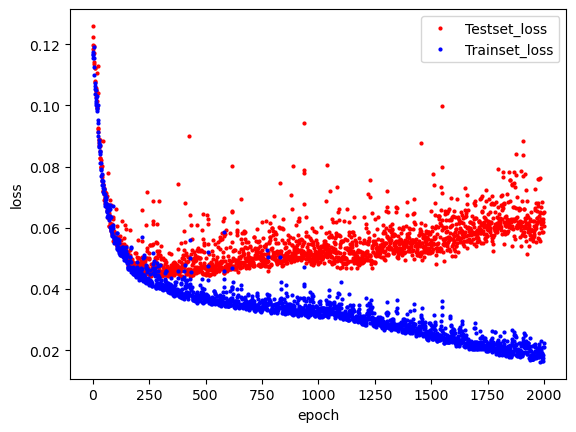

In [ ]:
# 검증 데이터(validation set)의 손실값만 따로 추출
# → 모델이 "시험"에서 얼마나 틀렸는지 나타냄
y_vloss=hist_df['val_loss']

# 훈련 데이터(training set)의 손실값만 따로 추출
# → 모델이 "공부"하면서 얼마나 틀렸는지 나타냄
y_loss=hist_df['loss']

# x축에 사용할 값 생성 (epoch 번호)
# → 0부터 (전체 epoch 수 - 1)까지의 숫자 배열 생성
# → loss 값 개수만큼 자동 생성됨
x_len=np.arange(len(y_loss))



# 검증 손실(val_loss)을 빨간색 점으로 그래프에 표시
# → epoch이 증가하면서 시험 성적이 어떻게 변하는지 확인
plt.plot(x_len, # x축: epoch 번호
         y_vloss,  #y축: 검증 손실 값
         "o",     # 점(point) 형태로 표시
         c="red", # 점 색상: 빨간색
         markersize=2, # 점 크기
         label='val_loss') # 범례에 표시될 이름


# 훈련 손실(loss)을 파란색 점으로 그래프에 표시
# → 학습이 진행되면서 훈련 오차가 줄어드는지 확인
plt.plot(x_len,   # x축: epoch 번호
         y_loss,    # y축: 훈련 손실 값
         "o",       # 점 형태로 표시
         c="blue",   # 점 색상: 파란색
         markersize=2,   # 점 크기
         label='Trainset_loss')   # 범례에 표시될 이름

# 그래프에 범례(설명 상자) 표시
# → 오른쪽 위 위치에 표시
plt.legend(loc='upper right')
# x축 이름 설정
# → epoch: 학습 반복 횟수
plt.xlabel('epoch')
# y축 이름 설정
# → loss: 오차(틀린 정도)
plt.ylabel('loss')
# 지금까지 설정한 그래프를 화면에 출력
plt.show()

## 학습 자동 중단

In [ ]:
# ===============================
# 1. 필요한 라이브러리 불러오기
# ===============================

# 신경망 모델을 순서대로 쌓기 위한 클래스
from tensorflow.keras.models import Sequential
# 완전연결층(Dense layer)을 만들기 위한 클래스
from tensorflow.keras.layers import Dense
# 데이터를 학습용(train)과 테스트용(test)으로 나누는 함수
from sklearn.model_selection import train_test_split

# 학습을 자동으로 제어하기 위한 콜백 함수들
# - ModelCheckpoint: 성능이 가장 좋을 때 모델 저장
# - EarlyStopping: 성능이 나빠지면 학습 중단
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping

# 파일 및 경로 관리를 위한 라이브러리
import os
# CSV 파일을 표 형태(DataFrame)로 다루기 위한 라이브러리
import pandas as pd

# ===============================
# 2. 데이터 불러오기
# ===============================

# wine.csv 파일을 읽어옴
# header=None → 첫 줄이 컬럼명이 아니므로 자동으로 0,1,2,... 번호 부여

df=pd.read_csv("./wine.csv",header=None)

# ===============================
# 3. 입력 데이터(X)와 정답(y) 분리
# ===============================

# 0번 열부터 11번 열까지 → 입력 데이터(특징, feature)
# 총 12개의 입력 변수
X=df.iloc[:,0:12]


# 12번 열 → 정답(label)
# 이진 분류 문제일 가능성이 큼 (0 또는 1)
y=df.iloc[:,12]

# ===============================
# 4. 학습용 / 테스트용 데이터 분리
# ===============================

# 전체 데이터 중
# - 80% → 학습용(train)
# - 20% → 테스트용(test)
# shuffle=True → 데이터 섞어서 나눔 (편향 방지)
X_train,X_test,y_train,y_test=train_test_split(X,
                                               y,
                                               test_size=0.2,
                                               shuffle=True)

# ===============================
# 5. 모델 생성
# ===============================

# Sequential 모델 생성
# → 층을 위에서 아래로 차례대로 쌓는 구조
# ⚠️ 기존 코드의 mode → model 로 오타 수정
model=Sequential()

# ===============================
# 6. 신경망 층(layer) 쌓기
# ===============================

# 첫 번째 은닉층
# - 노드 수: 30개
# - input_dim=12 → 입력 데이터 특성 개수
# - activation='relu' → 음수는 0, 양수는 그대로 사용
model.add(Dense(30,input_dim=12,activation='relu'))

# 두 번째 은닉층
# - 노드 수: 12개
# - 이전 층의 출력(30개)을 받아서 처리
model.add(Dense(12,activation='relu'))


# 세 번째 은닉층
# - 노드 수: 8개
# - 점점 더 중요한 정보만 추출
model.add(Dense(8,activation='relu'))

# 출력층
# - 노드 수: 1개
# - sigmoid → 0~1 사이 값 출력
# → 이진 분류 문제에 사용
model.add(Dense(1,activation='sigmoid'))

# ===============================
# 7. 모델 구조 요약 출력
# ===============================

# 각 층의 노드 수, 파라미터 수 확인
# → 내가 만든 신경망 구조를 한눈에 보기
model.summary()

# ===============================
# 8. 모델 컴파일 (학습 준비)
# ===============================
model.compile(loss='binary_crossentropy',  # 이진 분류 문제에서 사용하는 손실 함수
              # 가장 많이 쓰는 최적화 알고리즘
              # 학습률을 자동으로 조절해 줌
              optimizer='adam',
            # 학습 중 정확도를 함께 출력
              metrics=['accuracy'])

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 30)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 12)             │           372 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 30)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 12)             │           372 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,172 (12.39 KB)

 Trainable params: 1,420 (5.55 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,752 (6.85 KB)

In [ ]:
early_stopping_callback=EarlyStopping(monitor='val_loss',patience=20)

modelpath='./bestmodel.keras'

checkpointer=ModelCheckpoint(filepath=modelpath,monitor='val_loss',verbose=0,save_best_only=True)

history=model.fit(X_train,
                  y_train,
                  epochs=2000,
                  batch_size=500,
                  validation_split=0.25,
                  verbose=1,
                  callbacks=[early_stopping_callback,checkpointer])

Epoch 1/2000


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9828 - loss: 0.0750 - val_accuracy: 0.9862 - val_loss: 0.0581
Epoch 2/2000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9923 - loss: 0.0362 - val_accuracy: 0.9877 - val_loss: 0.0533
Epoch 3/2000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9936 - loss: 0.0303 - val_accuracy: 0.9923 - val_loss: 0.0379
Epoch 4/2000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9936 - loss: 0.0287 - val_accuracy: 0.9923 - val_loss: 0.0391
Epoch 5/2000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9949 - loss: 0.0279 - val_accuracy: 0.9931 - val_loss: 0.0382
Epoch 6/2000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9936 - loss: 0.0312 - val_accuracy: 0.9908 - val_loss: 0.0407
Epoch 7/2000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9938 - loss: 0.0308 - val_accuracy: 0.9908 - val_loss: 0.0403
Epoch 8/2000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9941 - loss: 0.0294 - val_accuracy: 0.9915 - val_loss: 0.0388
Ep

In [24]:
score=model.evaluate(X_test,y_test)
print('Test accuracy:',score[1])

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9931 - loss: 0.0310 
Test accuracy: 0.9930769205093384
